ARKANSAS - Mean NDVI per crop
Crop 0: Mean NDVI = 0.4566
Crop 1: Mean NDVI = 0.3545
Crop 2: Mean NDVI = 0.3321
Crop 3: Mean NDVI = 0.3306
Crop 5: Mean NDVI = 0.3367

CALIFORNIA - Mean NDVI per crop
Crop 0: Mean NDVI = 0.3931
Crop 3: Mean NDVI = 0.2925
Crop 36: Mean NDVI = 0.4390
Crop 69: Mean NDVI = 0.3800
Crop 75: Mean NDVI = 0.4514
Crop 204: Mean NDVI = 0.4508


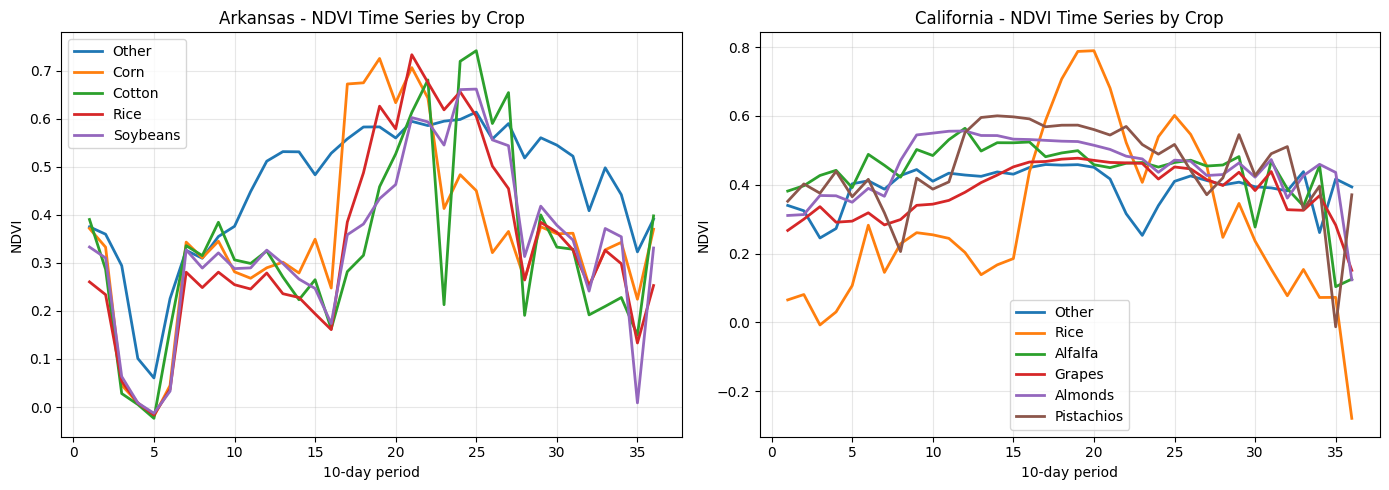


NDVI STATISTICS BY CROP

📊 ARKANSAS:
  Other        | Mean: 0.457 | Max: 0.613 | Min: 0.061 | Peak at t=25
  Corn         | Mean: 0.355 | Max: 0.725 | Min: -0.019 | Peak at t=19
  Cotton       | Mean: 0.332 | Max: 0.741 | Min: -0.024 | Peak at t=25
  Rice         | Mean: 0.331 | Max: 0.733 | Min: -0.017 | Peak at t=21
  Soybeans     | Mean: 0.337 | Max: 0.661 | Min: -0.013 | Peak at t=25

📊 CALIFORNIA:
  Other        | Mean: 0.393 | Max: 0.459 | Min: 0.245 | Peak at t=17
  Rice         | Mean: 0.292 | Max: 0.790 | Min: -0.279 | Peak at t=20
  Alfalfa      | Mean: 0.439 | Max: 0.564 | Min: 0.104 | Peak at t=12
  Grapes       | Mean: 0.380 | Max: 0.477 | Min: 0.151 | Peak at t=19
  Almonds      | Mean: 0.451 | Max: 0.556 | Min: 0.124 | Peak at t=12
  Pistachios   | Mean: 0.451 | Max: 0.600 | Min: -0.013 | Peak at t=14


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 1. LOAD DATA
# ============================================

# Arkansas
data_ark = pd.read_csv("../data/arkansas.csv")
y_ark = data_ark[" target_label"].values
features_ark = data_ark.values[:, :-1]
X_ark = features_ark.reshape(-1, 36, 13)[:, :, :10]  # (N, 36, 10)

# California
data_cal = pd.read_csv("../data/california.csv")
y_cal = data_cal["target_label"].values
features_cal = data_cal.values[:, :-1]
X_cal = features_cal.reshape(-1, 36, 13)[:, :, :10]  # (N, 36, 10)

# ============================================
# 2. NDVI COMPUTATION FUNCTION
# ============================================

def compute_ndvi(s2_data):
    """
    Calculate NDVI = (B8 - B4) / (B8 + B4)
    s2_data: (N, 36, 10) -> indices: B4=3 (Red), B8=7 (NIR)
    """
    b4 = s2_data[:, :, 3]  # Red band
    b8 = s2_data[:, :, 7]  # NIR band
    
    # Avoid division by zero
    denominator = b8 + b4
    ndvi = np.divide(b8 - b4, denominator, out=np.zeros_like(b8), where=denominator != 0)
    return ndvi  # (N, 36)

# ============================================
# 3. MEAN NDVI PER CROP
# ============================================

def mean_ndvi_by_crop(X, y):
    """
    Calculate mean NDVI for each crop class over the whole season
    """
    ndvi_all = compute_ndvi(X)  # (N, 36)
    unique_crops = np.unique(y)
    
    results = {}
    for crop in unique_crops:
        mask = (y == crop)
        ndvi_crop = ndvi_all[mask]  # (n_crop, 36)
        mean_ndvi = np.mean(ndvi_crop, axis=0)  # (36,)
        results[crop] = mean_ndvi
    
    return results, unique_crops

# Run for both regions
results_ark, crops_ark = mean_ndvi_by_crop(X_ark, y_ark)
results_cal, crops_cal = mean_ndvi_by_crop(X_cal, y_cal)

# ============================================
# 4. DISPLAY RESULTS
# ============================================

print("="*50)
print("ARKANSAS - Mean NDVI per crop")
print("="*50)
for crop in crops_ark:
    mean_year = np.mean(results_ark[crop])
    print(f"Crop {int(crop)}: Mean NDVI = {mean_year:.4f}")

print("\n" + "="*50)
print("CALIFORNIA - Mean NDVI per crop")
print("="*50)
for crop in crops_cal:
    mean_year = np.mean(results_cal[crop])
    print(f"Crop {int(crop)}: Mean NDVI = {mean_year:.4f}")

# ============================================
# 5. TEMPORAL NDVI SERIES VISUALIZATION
# ============================================

# Crop name mappings (adjust according to your CDL codes)
crop_names_ark = {
    1: "Corn", 2: "Cotton", 3: "Rice", 5: "Soybeans", 0: "Other"
}
crop_names_cal = {
    3: "Rice", 36: "Alfalfa", 69: "Grapes", 75: "Almonds", 204: "Pistachios", 0: "Other"
}

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
time_steps = range(1, 37)

# Arkansas
for crop in crops_ark:
    name = crop_names_ark.get(int(crop), f"Crop {int(crop)}")
    axes[0].plot(time_steps, results_ark[crop], label=name, linewidth=2)
axes[0].set_xlabel("10-day period")
axes[0].set_ylabel("NDVI")
axes[0].set_title("Arkansas - NDVI Time Series by Crop")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# California
for crop in crops_cal:
    name = crop_names_cal.get(int(crop), f"Crop {int(crop)}")
    axes[1].plot(time_steps, results_cal[crop], label=name, linewidth=2)
axes[1].set_xlabel("10-day period")
axes[1].set_ylabel("NDVI")
axes[1].set_title("California - NDVI Time Series by Crop")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/part1/ndvi_temporal_series.png", dpi=150)
plt.show()

# ============================================
# 6. SUMMARY STATISTICS
# ============================================

print("\n" + "="*50)
print("NDVI STATISTICS BY CROP")
print("="*50)

# Arkansas
print("\n📊 ARKANSAS:")
for crop in crops_ark:
    name = crop_names_ark.get(int(crop), f"Crop {int(crop)}")
    ndvi_vals = results_ark[crop]
    print(f"  {name:12} | Mean: {np.mean(ndvi_vals):.3f} | Max: {np.max(ndvi_vals):.3f} | Min: {np.min(ndvi_vals):.3f} | Peak at t={np.argmax(ndvi_vals)+1}")

# California
print("\n📊 CALIFORNIA:")
for crop in crops_cal:
    name = crop_names_cal.get(int(crop), f"Crop {int(crop)}")
    ndvi_vals = results_cal[crop]
    print(f"  {name:12} | Mean: {np.mean(ndvi_vals):.3f} | Max: {np.max(ndvi_vals):.3f} | Min: {np.min(ndvi_vals):.3f} | Peak at t={np.argmax(ndvi_vals)+1}")